In [61]:
# Imports and Setup
import pandas as pd
import numpy as np
import mne
from glob import glob
from os.path import join as ospj
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

# ===== CONFIGURATION (Standalone) =====
# Data directories
DATA_DIR = "/mnt/leif/littlab/users/pattnaik/ieeg_sz_embedding/data"
RAW_DATA_DIR = "/mnt/leif/littlab/data/Human_Data/CNT_iEEG_BIDS"

# Load seizure times from Excel
sz_times = pd.read_excel(
    ospj(DATA_DIR, "metadata/Manual validation.xlsx"),
    sheet_name="AllSeizureTimes",
    index_col=0,
)

# Load RID-HUP mapping table
rid_hup_table = pd.read_csv(
    ospj(DATA_DIR, "metadata/rid_hup_table.csv"), index_col=0
)
rid_hup_table.dropna(inplace=True, subset=["hupsubjno"])
for ind, row in rid_hup_table.iterrows():
    rid_hup_table.loc[ind, "hupsubjno"] = int(row["hupsubjno"][:3])

rid_hup_table.index = [f"sub-RID{x:04d}" for x in rid_hup_table.index]
rid_hup_table['hupsubjno'] = [f"HUP{x:03d}" for x in rid_hup_table['hupsubjno']]

# Create mapping dictionaries
rid_to_hup = rid_hup_table['hupsubjno'].to_dict()
hup_to_rid = {v: k for k, v in rid_to_hup.items()}

# Clean up sz_times
sz_times.dropna(inplace=True, subset=["IEEGname"])
sz_times = sz_times[sz_times["IEEGname"] != "HUP203_phaseII"]  # No RID for this subject

# Create sz_table with RID indices
sz_table = sz_times.copy()
sz_table.index = sz_table.index.map(hup_to_rid)
sz_table.reset_index(inplace=True)

print(f"✓ Loaded {len(sz_table)} seizures from sz_times")
print(f"✓ Columns: {sz_table.columns.tolist()}")
print(f"✓ Configuration loaded successfully (standalone mode)")


✓ Loaded 1501 seizures from sz_times
✓ Columns: ['Patient', 'IEEGID', 'IEEGname', 'start', 'end', 'source', 'notes', 'Semiology']
✓ Configuration loaded successfully (standalone mode)


In [62]:
# Build Seizure Cache Dictionary
def build_seizure_cache():
    """
    Build a cache dictionary mapping seizure indices to EDF file paths and seizure times.
    
    Returns:
        dict: Cache dictionary with structure:
              {seizure_index: {'edf_path': str, 'onset': float, 'offset': float, 'patient': str}}
    """
    seizure_cache = {}
    missing_files = []
    
    print("Building seizure cache...")
    for ind, row in tqdm(sz_table.iterrows(), total=len(sz_table)):
        # Find EDF file using glob pattern (same as make_dataset.py lines 49-54)
        fname = glob(
            ospj(
                RAW_DATA_DIR,
                row.Patient,
                "ses-clinical01/ieeg",
                f"{row.Patient}_ses-clinical01_task-ictal{int(row.start)}_*.edf"
            )
        )
        
        if len(fname) == 0:
            missing_files.append([ind, row.Patient, "No file found"])
            continue
        if len(fname) > 1:
            missing_files.append([ind, row.Patient, "Multiple files found"])
            continue
        
        # Store seizure info in cache
        seizure_cache[ind] = {
            'edf_path': fname[0],
            'onset': row.start if 'start' in row else None,
            'offset': row.end if 'end' in row else None,
            'patient': row.Patient
        }
    
    print(f"✓ Cached {len(seizure_cache)} seizures")
    print(f"✗ Missing files for {len(missing_files)} seizures")
    
    if missing_files:
        print("\nMissing files summary:")
        for idx, patient, reason in missing_files[:5]:  # Show first 5
            print(f"  - Index {idx} ({patient}): {reason}")
        if len(missing_files) > 5:
            print(f"  ... and {len(missing_files) - 5} more")
    
    return seizure_cache, missing_files

# Build the cache
seizure_cache, missing_files = build_seizure_cache()
print(f"\nCache built with {len(seizure_cache)} seizures")


Building seizure cache...


100%|██████████| 1501/1501 [00:05<00:00, 274.20it/s]

✓ Cached 1499 seizures
✗ Missing files for 2 seizures

Missing files summary:
  - Index 499 (sub-RID0365): No file found
  - Index 921 (sub-RID0472): No file found

Cache built with 1499 seizures


In [63]:
# Load Seizure Data Function
def load_seizure_data(seizure_idx, padding_before=30, padding_after=15):
    """
    Load and crop EDF file for a specific seizure with configurable time padding.
    
    Parameters:
    -----------
    seizure_idx : int
        Index of the seizure in the cache dictionary
    padding_before : float, default=30
        Time in seconds to include before seizure onset
    padding_after : float, default=15
        Time in seconds to include after seizure offset
    
    Returns:
    --------
    dict : Dictionary containing:
        - 'raw_cropped': mne.io.Raw object with the cropped data
        - 'seizure_idx': seizure index
        - 'patient': patient ID
        - 'onset': seizure onset time (from metadata)
        - 'offset': seizure offset time (from metadata)
        - 'seizure_start_in_file': time in file where seizure starts
        - 'seizure_duration': duration of seizure
        - 'tmin': start time of crop in file
        - 'tmax': end time of crop in file
        - 'padding_before': padding before onset
        - 'padding_after': padding after offset
    """
    
    # Check if seizure exists in cache
    if seizure_idx not in seizure_cache:
        raise ValueError(f"Seizure index {seizure_idx} not found in cache. "
                        f"Available indices: {list(seizure_cache.keys())[:10]}...")
    
    # Get seizure info from cache
    sz_info = seizure_cache[seizure_idx]
    edf_path = sz_info['edf_path']
    onset = sz_info['onset']
    offset = sz_info['offset']
    patient = sz_info['patient']
    
    print(f"Loading seizure {seizure_idx} for patient {patient}")
    print(f"  EDF file: {os.path.basename(edf_path)}")
    print(f"  Onset: {onset}s, Offset: {offset}s")
    
    # Load EDF file
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    
    # Get annotations to find where the seizure actually starts in the file
    # Based on make_dataset.py logic: if annotation onset is 30s, the seizure starts at 30s
    if len(raw.annotations) > 0 and raw.annotations.onset[0] == 30:
        seizure_start_in_file = 30.0
    else:
        seizure_start_in_file = 0.0
    
    # Calculate the seizure duration
    seizure_duration = offset - onset
    
    # Calculate time window in the file
    tmin = max(0, seizure_start_in_file - padding_before)
    tmax = min(raw.times[-1], seizure_start_in_file + seizure_duration + padding_after)
    
    print(f"  Cropping from {tmin:.1f}s to {tmax:.1f}s (duration: {tmax-tmin:.1f}s)")
    
    # Crop data to time window
    raw_cropped = raw.copy().crop(tmin=tmin, tmax=tmax)
    
    print(f"  Loaded {len(raw_cropped.ch_names)} channels at {raw_cropped.info['sfreq']} Hz")
    
    # Return all relevant information
    return {
        'raw_cropped': raw_cropped,
        'seizure_idx': seizure_idx,
        'patient': patient,
        'onset': onset,
        'offset': offset,
        'seizure_start_in_file': seizure_start_in_file,
        'seizure_duration': seizure_duration,
        'tmin': tmin,
        'tmax': tmax,
        'padding_before': padding_before,
        'padding_after': padding_after,
    }



RAW DATA SIZE AND INFORMATION

Data Shape:
  Channels: 50
  Samples: 54,000
  Duration: 108.00 seconds
  Sampling Frequency: 500.0 Hz
  Data Size in Memory: 20.60 MB

NumPy Array Shape: (50, 54000)
  (channels, time_points)

SEIZURE ANNOTATIONS

Seizure Index: 140
Patient: sub-RID0179

Metadata Timing:
  Onset in original file: 75640.38 s
  Offset in original file: 75718.38 s
  Duration: 78.00 s

Cropped Data Timing:
  File cropped from: 0.00 s to 108.00 s
  Seizure starts at: 30.00 s in original file
  Padding before: 30 s
  Padding after: 15 s

Seizure Position in Cropped Data:
  Onset: 30.00 s
  Offset: 108.00 s

MNE Annotations in Data:
  Number of annotations: 1
  [0] Onset: 30.00s, Duration: 78.00s, Description: 'ictal'


✓ Using Cairo backend for SVG rendering
✓ Simple plotting function defined (with SVG export)


In [80]:
# Example 1: Plot subset of channels (20 channels for clarity)
import matplotlib
matplotlib.use("cairo")
data  = load_seizure_data(140)
print("Plotting 20 evenly-spaced channels...")
fig, ax,_ = plot_ieeg_simple(data, figsize=(16, 10))
plt.show()

print("\nNote: Red dashed line = Seizure Onset")
print("      Blue dashed line = Seizure Offset")
print("      Red shaded area = Seizure Period")

Loading seizure 140 for patient sub-RID0179
  EDF file: sub-RID0179_ses-clinical01_task-ictal75640_run-01_ieeg.edf
  Onset: 75640.38s, Offset: 75718.38s
  Cropping from 0.0s to 108.0s (duration: 108.0s)
  Loaded 50 channels at 500.0 Hz
Plotting 20 evenly-spaced channels...
✓ Saved to: ieeg_plot_sub-RID0179_sz140.svg

Note: Red dashed line = Seizure Onset
      Blue dashed line = Seizure Offset
      Red shaded area = Seizure Period


Zooming into seizure onset: 20.0s to 40.0s


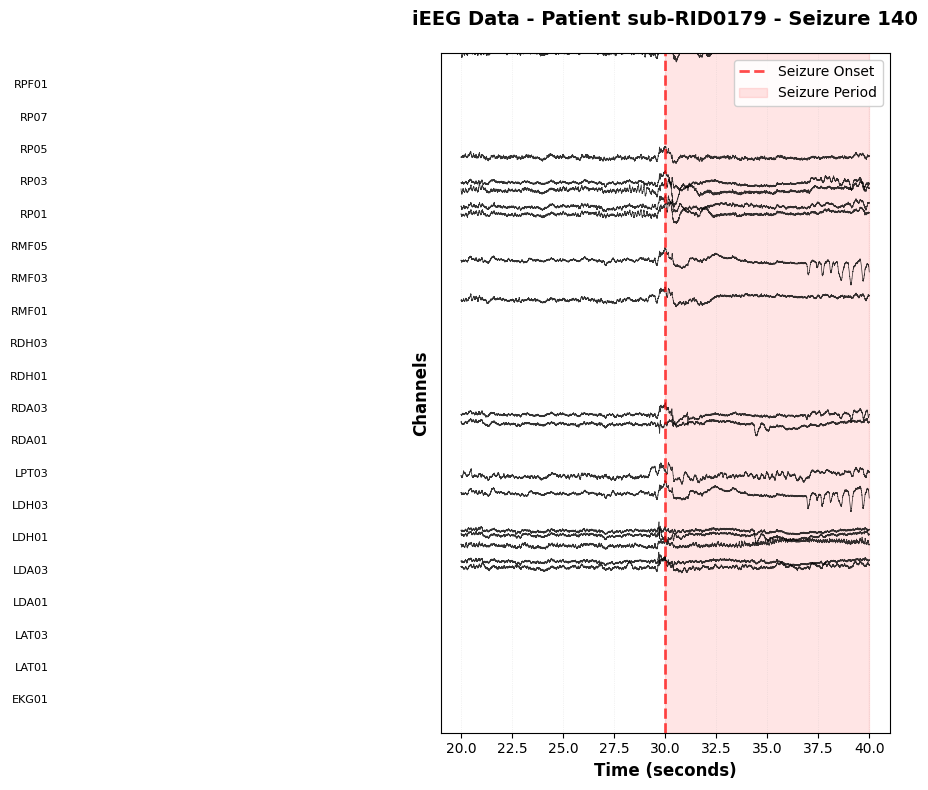

Plotting all 50 channels...


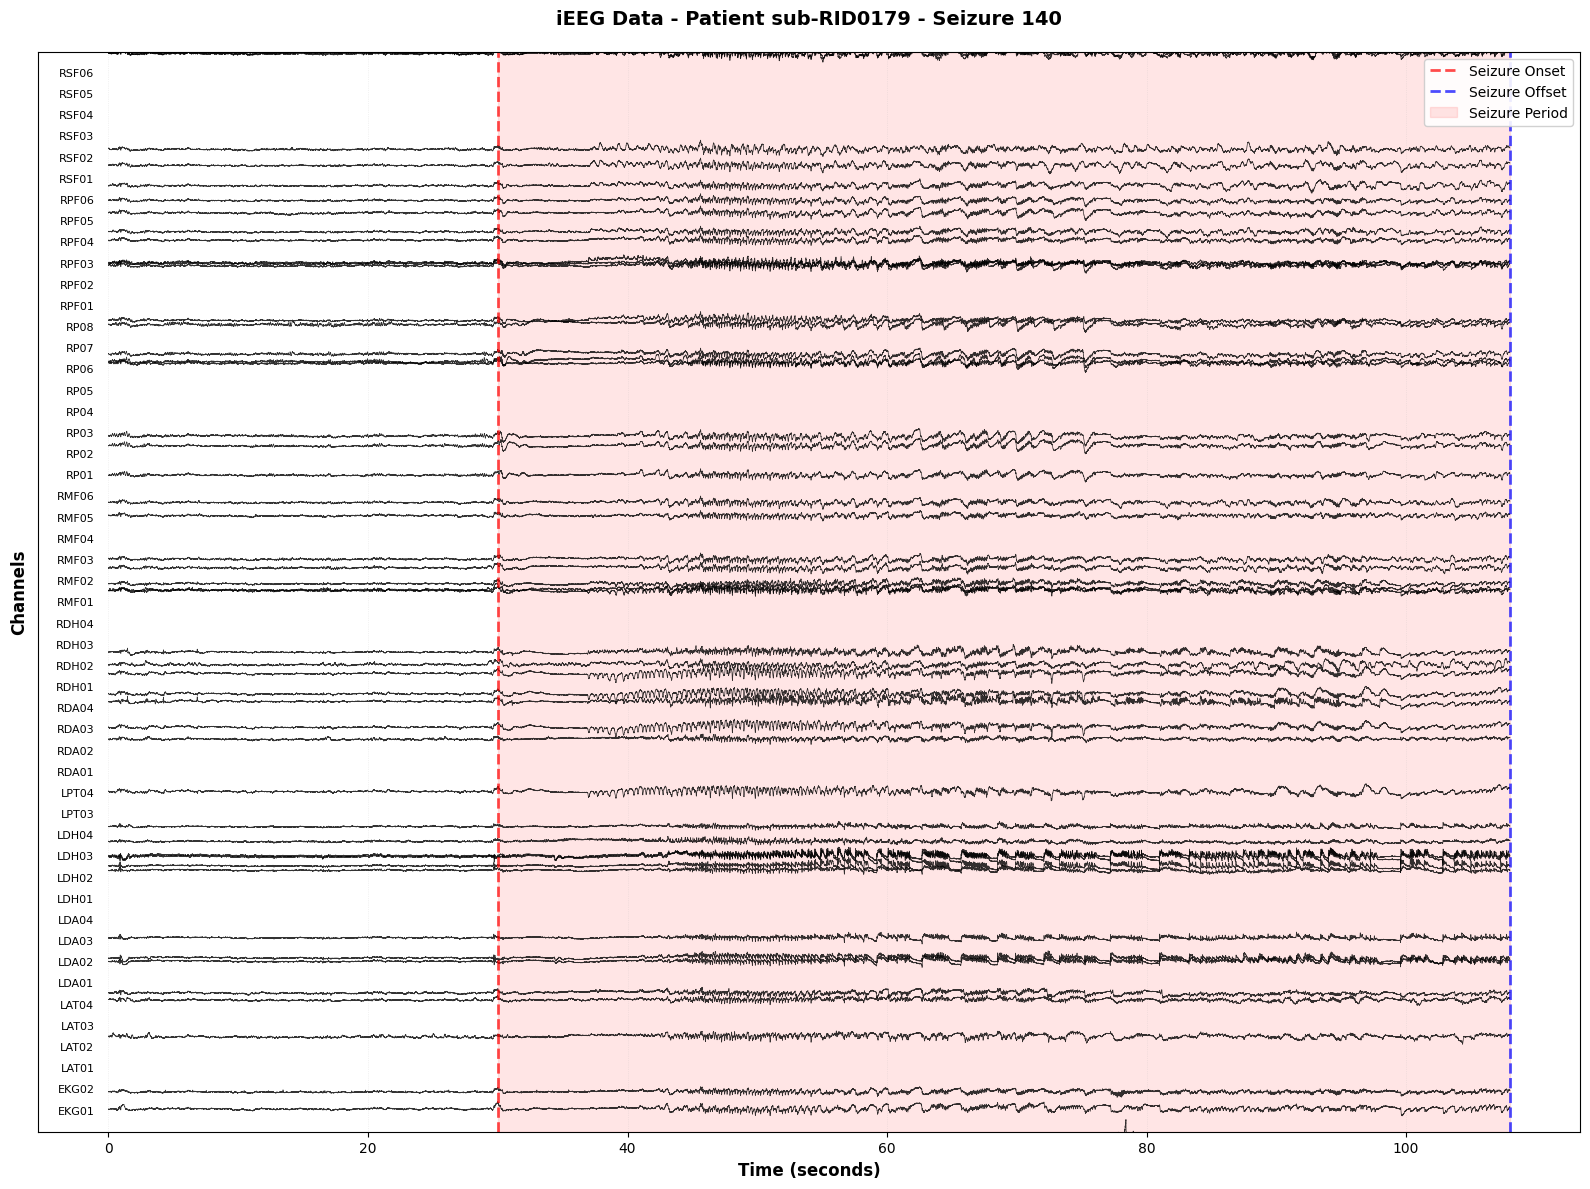


FLEXIBILITY OPTIONS:
The plot_ieeg_data() function supports:
  • channel_subset: Plot N evenly-spaced channels
  • channels: List of specific channel indices or names
  • time_range: (tmin, tmax) to zoom into specific time window
  • scale: Adjust signal amplitude scaling
  • spacing: Control vertical spacing between channels
  • figsize: Adjust figure dimensions
  • show_seizure_markers: Toggle seizure onset/offset markers

Example custom calls:
  plot_ieeg_data(data, channels=[0,1,2,3,4], scale=2.0)
  plot_ieeg_data(data, time_range=(20, 40), spacing=5000)
  plot_ieeg_data(data, show_seizure_markers=False)


✓ Plotting function updated with FIXED uniform spacing!

The spacing is now uniform across all channels.
Every channel has the same gap, based on the maximum signal range.

Plotting 20 evenly-spaced channels with fixed spacing...


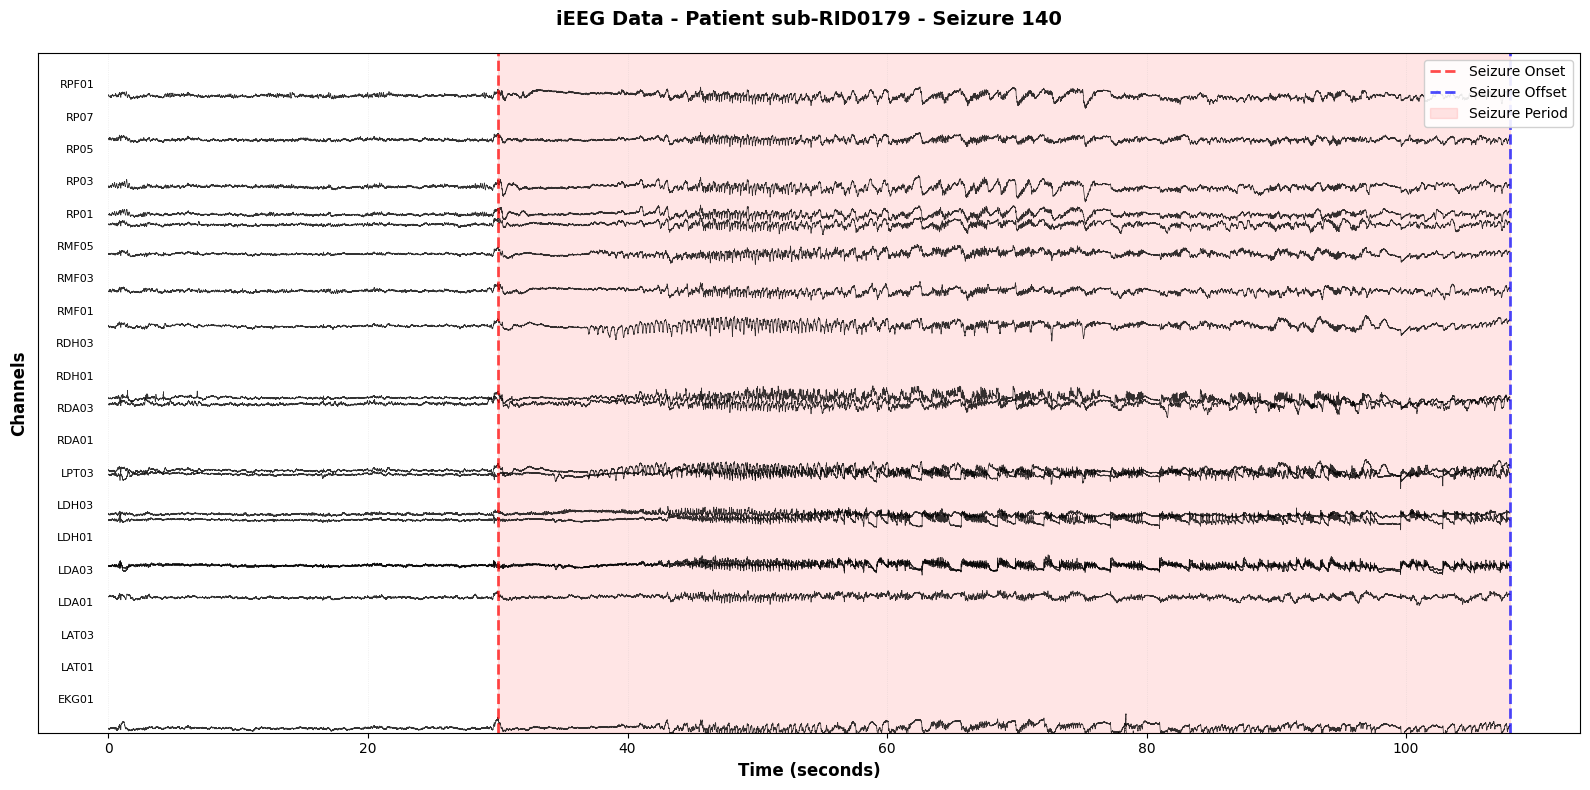


✓ All gaps between channels are now equal!
   (Previously: some channels had big gaps, some had small gaps)
   (Now: uniform spacing based on the largest signal amplitude)


TypeError: plot_ieeg_simple() got an unexpected keyword argument 'save_path'

In [87]:
# Model Window Visualization Function
def plot_model_windows(data_dict, channel_idx, time_start=30, time_end=90, 
                       window_size=1.0, padding=0.5, show_boxes=True,
                       box_height=None, figsize=(20, 6), save_path=None):
    """
    Plot a single channel with boxes showing model input windows.
    Only plots data within the boxes for easy editing in Illustrator.
    
    Parameters:
    -----------
    data_dict : dict
        Dictionary returned by load_seizure_data()
    channel_idx : int
        Index of channel to plot
    time_start : float
        Start time in seconds (default 30)
    time_end : float
        End time in seconds (default 90)
    window_size : float
        Core window size in seconds (default 1.0)
    padding : float
        Padding on each side in seconds (default 0.5)
    show_boxes : bool
        Whether to draw boxes around windows (default True)
    box_height : float or None
        Fixed height for all boxes. If None, auto-calculated from data range.
    figsize : tuple
        Figure size (width, height)
    save_path : str or None
        Path to save SVG file
    
    Returns:
    --------
    fig, ax, save_path
    """
    
    raw = data_dict['raw_cropped']
    data_array = raw.get_data()
    times = raw.times
    ch_names = raw.ch_names
    sfreq = raw.info['sfreq']
    
    # Get single channel
    channel_data = data_array[channel_idx, :]
    channel_name = ch_names[channel_idx]
    
    # Re-center signal
    channel_data = channel_data - channel_data.mean()
    
    # Calculate fixed box height if not provided
    if box_height is None:
        # Use the data range in the time window
        idx_start_range = int(time_start * sfreq)
        idx_end_range = int(time_end * sfreq)
        data_range = np.ptp(channel_data[idx_start_range:idx_end_range])
        box_height = data_range * 1.2  # 20% margin
    
    box_y_center = 0  # Center around 0 since data is centered
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Generate window centers (every 1 second in the range)
    window_centers = np.arange(time_start + window_size/2, time_end, window_size)
    
    # Plot each window
    for center in window_centers:
        # Calculate window boundaries
        win_start = center - window_size/2 - padding
        win_end = center + window_size/2 + padding
        
        # Get indices
        idx_start = int(win_start * sfreq)
        idx_end = int(win_end * sfreq)
        
        # Extract window data
        if idx_start >= 0 and idx_end < len(times):
            win_times = times[idx_start:idx_end]
            win_data = channel_data[idx_start:idx_end]
            
            # Plot the data within this window
            ax.plot(win_times, win_data, 'k', linewidth=0.8)
            
            # Draw box around the core window (without padding) if enabled
            if show_boxes:
                core_start = center - window_size/2
                
                # Draw rectangle with fixed height
                rect = plt.Rectangle((core_start, box_y_center - box_height/2), 
                                    window_size, box_height,
                                    linewidth=1.5, edgecolor='red', 
                                    facecolor='none', linestyle='--')
                ax.add_patch(rect)
    
    # Formatting
    ax.set_xlabel('Time (s)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Amplitude (μV)', fontsize=12, fontweight='bold')
    ax.set_title(f'Model Window Analysis - Channel: {channel_name} - Patient {data_dict["patient"]}',
                fontsize=14, fontweight='bold')
    ax.set_xlim(time_start, time_end)
    ax.grid(True, alpha=0.3, linestyle=':')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        plt.Line2D([0], [0], color='k', linewidth=0.8, 
                   label=f'Data (window + {padding}s padding)')
    ]
    if show_boxes:
        legend_elements.insert(0, 
            Patch(facecolor='none', edgecolor='red', linestyle='--', 
                  label=f'Core window ({window_size}s)'))
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
    
    # Auto-generate save path if not provided
    if save_path is None:
        save_path = f"model_windows_{data_dict['patient']}_ch{channel_idx}_{channel_name}.svg"
    
    # Save as SVG
    fig.savefig(save_path, format='svg', bbox_inches='tight', dpi=300)
    print(f"✓ Saved to: {save_path}")
    
    return fig, ax, save_path

print("✓ Model window visualization function defined")

✓ Model window visualization function defined


In [88]:
# Example 1: Plot with same-size boxes
print("=" * 70)
print("MODEL WINDOW VISUALIZATION - WITH BOXES")
print("=" * 70)
print(f"\nShowing how model processes channel 0 between 30-90 seconds")
print(f"Window size: 1.0 second")
print(f"Padding: 0.5 seconds on each side")
print(f"All boxes have the SAME fixed height\n")

# Plot channel 0 with fixed-size boxes
fig, ax, svg_path = plot_model_windows(
    data, 
    channel_idx=-1,
    time_start=30, 
    time_end=90,
    window_size=1.0,
    padding=0.5,
    show_boxes=False,      # Show boxes
    figsize=(20, 6)
)
plt.show()

print(f"\n✓ All red boxes = same size (1 second core window)")
print(f"✓ Black lines = actual data (includes 0.5s padding on each side)")
print(f"✓ Easy to edit individual windows in Adobe Illustrator!")
print(f"\nTotal windows shown: {len(ax.patches)}")

MODEL WINDOW VISUALIZATION - WITH BOXES

Showing how model processes channel 0 between 30-90 seconds
Window size: 1.0 second
Padding: 0.5 seconds on each side
All boxes have the SAME fixed height

✓ Saved to: model_windows_sub-RID0179_ch-1_RSF06.svg

✓ All red boxes = same size (1 second core window)
✓ Black lines = actual data (includes 0.5s padding on each side)
✓ Easy to edit individual windows in Adobe Illustrator!

Total windows shown: 0


In [ ]:
# Example 2: Plot WITHOUT boxes
print("\n" + "=" * 70)
print("MODEL WINDOW VISUALIZATION - WITHOUT BOXES")
print("=" * 70)
print(f"\nSame data, but boxes are hidden (show_boxes=False)\n")

# Plot without boxes
fig, ax, svg_path = plot_model_windows(
    data, 
    channel_idx=0,
    time_start=30, 
    time_end=90,
    window_size=1.0,
    padding=0.5,
    show_boxes=False,     # Hide boxes
    figsize=(20, 6)
)
plt.show()

print(f"\n✓ No boxes shown - just the windowed data")
print(f"✓ Clean for final figures or further editing")
print(f"✓ Each line segment = window + padding")

# Additional examples
print("\n" + "=" * 70)
print("USAGE EXAMPLES")
print("=" * 70)

print("\n1. With boxes (default):")
print("   fig, ax, path = plot_model_windows(data, channel_idx=0)")

print("\n2. Without boxes:")
print("   fig, ax, path = plot_model_windows(data, channel_idx=0, show_boxes=False)")

print("\n3. Custom box height:")
print("   fig, ax, path = plot_model_windows(data, channel_idx=0, box_height=500)")

print("\n4. Different time range:")
print("   fig, ax, path = plot_model_windows(data, channel_idx=0,")
print("                                        time_start=40, time_end=50)")

print("\n5. Custom window/padding:")
print("   fig, ax, path = plot_model_windows(data, channel_idx=0,")
print("                                        window_size=2.0, padding=1.0)")

print("\n" + "=" * 70)
print("KEY FEATURES:")
print("=" * 70)
print("✓ All boxes have SAME fixed height (not per-window min/max)")
print("✓ Optional box display with show_boxes argument")
print("✓ Only data within windows is plotted (separate line segments)")
print("✓ Easy to select and modify individual windows in Illustrator")
print("✓ Each window is a separate path object in the SVG")


ADDITIONAL EXAMPLES

1. Plot channel 5 with same settings:
   fig, ax, path = plot_model_windows(data, channel_idx=5)

2. Focus on shorter time range (40-50s):
   fig, ax, path = plot_model_windows(data, channel_idx=0,
                                        time_start=40, time_end=50)

3. Larger windows (2s window, 1s padding):
   fig, ax, path = plot_model_windows(data, channel_idx=0,
                                        window_size=2.0, padding=1.0)

4. Custom filename:
   fig, ax, path = plot_model_windows(data, channel_idx=0,
                                        save_path='my_analysis.svg')

KEY FEATURES:
✓ Only data within windows is plotted (separate line segments)
✓ Easy to select and modify individual windows in Illustrator
✓ Red boxes show the 1-second core window the model sees
✓ Black lines include padding data (context for the model)
✓ Each window is a separate path object in the SVG


In [85]:
fig, ax, path = plot_model_windows(data, channel_idx=-1)

✓ Saved to: model_windows_sub-RID0179_ch-1_RSF06.svg


In [ ]:
raw = data['raw_cropped']
data_array = raw.get_data()

data_array.shape

(50, 54000)